Training Parameter-Efficient LoRA Transformer Model...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4297 - loss: 0.7536
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6094 - loss: 0.6355
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8438 - loss: 0.5349
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9062 - loss: 0.4830
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9766 - loss: 0.4104
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9844 - loss: 0.3537
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9922 - loss: 0.2987
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.2407
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.1869
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1509

PARAMETER AUDIT RESULTS
Total Model Parameters   : 19,256
Frozen Base Parameters   : 518
Trainable LoRA Parameter

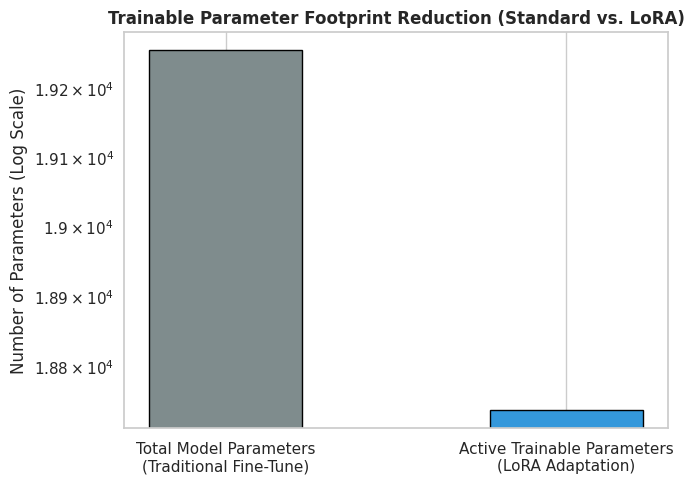

In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import tensorflow as tf  # deep learning
from tensorflow import keras  # model engine
from tensorflow.keras import layers  # network layers
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide tf logs
warnings.filterwarnings('ignore')  # silence warnings

SEED = 42  # standard seed
np.random.seed(SEED)  # seed numpy
tf.random.set_seed(SEED)  # seed tensorflow

# ==========================================
# Parameter-Efficient LoRA Layer
# ==========================================

class LoRADense(layers.Layer):  # custom lora layer
    def __init__(self, units, rank=4, alpha=1.0, **kwargs):  # initialization method
        super().__init__(**kwargs)  # parent init
        self.units = units  # output dimension size
        self.rank = rank  # scaling factor bottleneck
        self.scaling = alpha / rank  # normalization scaling coefficient

    def build(self, input_shape):  # weight creation method
        in_dim = input_shape[-1]  # input dimension size

        # Frozen base weight matrix
        self.w = self.add_weight(  # pre-trained matrix
            shape=(in_dim, self.units),  # dimension shapes
            initializer="glorot_uniform",  # random distribution initializer
            trainable=False,  # lock parameter updates (frozen)
            name="w_frozen"  # variable label
        )  # end weight definition

        self.bias = self.add_weight(  # linear bias
            shape=(self.units,),  # dimension shapes
            initializer="zeros",  # zero initializer
            trainable=True,  # unlock updates (trainable)
            name="bias"  # variable label
        )  # end weight definition

        # Trainable low-rank matrix A (Down-projection)
        self.lora_a = self.add_weight(  # bottleneck down-projection matrix
            shape=(in_dim, self.rank),  # dimension shapes
            initializer="he_uniform",  # uniform he distribution initializer
            trainable=True,  # unlock updates (trainable)
            name="lora_a"  # variable label
        )  # end weight definition

        # Trainable low-rank matrix B (Up-projection)
        self.lora_b = self.add_weight(  # bottleneck up-projection matrix
            shape=(self.rank, self.units),  # dimension shapes
            initializer="zeros",  # initialized to zeros so delta_W starts at 0
            trainable=True,  # unlock updates (trainable)
            name="lora_b"  # variable label
        )  # end weight definition

    def call(self, inputs):  # feedforward graph method
        base_out = tf.matmul(inputs, self.w) + self.bias  # pre-trained baseline calculation
        lora_out = tf.matmul(tf.matmul(inputs, self.lora_a), self.lora_b) * self.scaling  # delta_w low-rank calculation
        return base_out + lora_out  # combine outputs

# ==========================================
# Token & Position Embedding Module
# ==========================================

class TokenAndPositionEmbedding(layers.Layer):  # embedding block
    def __init__(self, maxlen, vocab_size, embed_dim):  # initialization method
        super().__init__()  # parent init
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)  # token embeddings lookup
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)  # position embeddings lookup

    def call(self, x):  # feedforward graph method
        maxlen = tf.shape(x)[-1]  # get active sequence length
        positions = tf.range(start=0, limit=maxlen, delta=1)  # generate index range sequence
        positions = self.pos_emb(positions)  # compute position vectors
        x = self.token_emb(x)  # compute token vectors
        return x + positions  # fuse embeddings

# ==========================================
# Parameter-Efficient Transformer Block
# ==========================================

class LoRATransformerBlock(layers.Layer):  # custom lora block
    def __init__(self, embed_dim, num_heads, ff_dim, rank=4, rate=0.1):  # initialization method
        super().__init__()  # parent init
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)  # multihead attention layer
        self.ffn_1 = LoRADense(ff_dim, rank=rank)  # first feed-forward lora layer
        self.ffn_2 = LoRADense(embed_dim, rank=rank)  # second feed-forward lora layer
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)  # normalize layer 1
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)  # normalize layer 2
        self.dropout1 = layers.Dropout(rate)  # regularizing dropout 1
        self.dropout2 = layers.Dropout(rate)  # regularizing dropout 2

    def call(self, inputs, training=False):  # feedforward graph method
        attn_output = self.att(inputs, inputs)  # calculate attention outputs
        attn_output = self.dropout1(attn_output, training=training)  # apply attention dropout
        out1 = self.layernorm1(inputs + attn_output)  # apply first residual normalize
        ffn_output = self.ffn_1(out1)  # run ffn layer 1
        ffn_output = tf.keras.activations.relu(ffn_output)  # activate intermediate representations
        ffn_output = self.ffn_2(ffn_output)  # run ffn layer 2
        ffn_output = self.dropout2(ffn_output, training=training)  # apply output dropout
        return self.layernorm2(out1 + ffn_output)  # apply second residual normalize

# ==========================================
# Build & Compile Model
# ==========================================

def build_lora_model(vocab_size=1000, maxlen=20, embed_dim=16, num_heads=2, ff_dim=16, rank=2):  # model compiler factory
    inputs = layers.Input(shape=(maxlen,))  # input node
    embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)  # embedding instance
    x = embedding_layer(inputs)  # inject features
    transformer_block = LoRATransformerBlock(embed_dim, num_heads, ff_dim, rank=rank)  # transformer instance
    x = transformer_block(x)  # pass sequences
    x = layers.GlobalAveragePooling1D()(x)  # pool temporal dimensional states
    x = layers.Dropout(0.1)(x)  # regularizing output dropout
    outputs = layers.Dense(2, activation="softmax")(x)  # classification node
    return keras.Model(inputs=inputs, outputs=outputs)  # compile keras model

# Build a compact LoRA network
model = build_lora_model()  # build architecture
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])  # compile setup

# Generate simple synthetic sequence dataset
x_train = np.random.randint(0, 1000, (128, 20))  # synthetic text tokens
y_train = np.random.randint(0, 2, (128,))  # synthetic binary targets

print("Training Parameter-Efficient LoRA Transformer Model...")  # status log
model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)  # train network

# ==========================================
# Parameter Audit & Metrics Analysis
# ==========================================

# Calculate trainable vs frozen parameters count
trainable_count = np.sum([np.prod(v.shape) for v in model.trainable_variables])  # sum trainable params
non_trainable_count = np.sum([np.prod(v.shape) for v in model.non_trainable_variables])  # sum frozen params
total_count = trainable_count + non_trainable_count  # calculate absolute total parameters

print("\n=====================================")
print("PARAMETER AUDIT RESULTS")
print("=====================================")
print(f"Total Model Parameters   : {total_count:,}")  # display total
print(f"Frozen Base Parameters   : {non_trainable_count:,}")  # display frozen
print(f"Trainable LoRA Parameters: {trainable_count:,}")  # display active trainable
print(f"Trainable Parameters %   : {(trainable_count / total_count) * 100:.2f}%")  # parameter savings percentage
print("=====================================")

# ==========================================
# Visualizing Parameter Savings
# ==========================================

# Show parameter comparison chart
sns.set_theme(style="whitegrid")  # set theme
plt.figure(figsize=(7, 5))  # canvas layout
categories = ['Total Model Parameters\n(Traditional Fine-Tune)', 'Active Trainable Parameters\n(LoRA Adaptation)']  # categories
counts = [total_count, trainable_count]  # parameters arrays
plt.bar(categories, counts, color=['#7f8c8d', '#3498db'], width=0.45, edgecolor='black')  # draw bars
plt.ylabel('Number of Parameters (Log Scale)')  # y label
plt.yscale('log')  # use logarithmic scale to emphasize differences
plt.title('Trainable Parameter Footprint Reduction (Standard vs. LoRA)', fontsize=12, fontweight='bold')  # plot title
plt.tight_layout()  # fit layout
plt.show()  # render plot